# Correlation Functions and Coarsening Dynamics

Spatial correlations and coarsening dynamics are two sides of the same coin. The equilibrium correlation function $G(r) = \langle \vec{s}_0 \cdot \vec{s}_r \rangle$ encodes the spatial structure of the ordered or disordered phase at a given temperature. When a system is suddenly quenched from a disordered initial condition into the ordered regime, a characteristic coarsening length scale $R(t)$ grows with Monte Carlo time according to power laws that characterize the non-equilibrium dynamic universality class [[1]](#Bibliography) [[2]](#Bibliography). For the Ising model, $R(t)$ measures the size of sharp Bloch-wall domains. For the XY model, it tracks the spacing between annihilating vortex-antivortex pairs rather than any sharp domain boundary.

This notebook presents both topics side by side for the three VibeSpin models (Ising, XY, and $q$-state clock), connecting the equilibrium correlation structure in Part I to the non-equilibrium coarsening dynamics in Part II. Part I loads or computes equilibrium $G(r)$ at representative temperatures. Part II loads or computes ordering kinetics traces showing how the coarsening length scale $R(t)$ evolves after a quench, with power-law fits that extract the growth exponent. The setup cell below imports the required libraries and defines the physical constants and color palette used throughout.

In [56]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from models.ising_model import IsingSimulation
from models.xy_model import XYSimulation
from models.clock_model import ClockSimulation
from utils.equilibration import convergence_equilibrate
from utils.observables import get_averaged_correlation


def _find_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'results').exists():
            return candidate
    return cwd


REPO_ROOT = _find_repo_root()
TC_ISING = 2.0 / np.log(1.0 + np.sqrt(2.0))
T_BKT = 0.893

PALETTE = {
    'ising': '#4878CF',
    'xy': '#6ACC65',
    'clock': '#EE854A',
    'ferro': '#4878CF',
    'crit': '#D65F5F',
    'para': '#6ACC65',
}

plt.rcParams['figure.dpi'] = 120

print(f'T_c (Ising, exact) = {TC_ISING:.4f}')
print(f'T_BKT (XY, theoretical) = {T_BKT}')
print(f'Repository root: {REPO_ROOT}')

T_c (Ising, exact) = 2.2692
T_BKT (XY, theoretical) = 0.893
Repository root: /workspaces/vibespin


---

## Part I: Equilibrium Correlation Functions

The equilibrium spin-spin correlation function is computed via the structure-factor route: the Fourier transform of the spin field yields $S(\mathbf{k})$, and radial averaging of the inverse transform gives $G(r)$ normalized to $G(0) = 1$. This Wiener-Khinchin approach avoids $O(N^2)$ real-space pair counting.

### Ising Correlations

The Ising model has three qualitatively different correlation regimes. In the ferromagnetic phase ($T < T_c$) correlations saturate to a long-range plateau. At the critical point ($T = T_c$) the decay is algebraic: $G(r) \sim r^{-\eta}$ with the exact exponent $\eta = 1/4$ [[3]](#Bibliography). In the paramagnetic phase ($T > T_c$) the decay is exponential with a correlation length $\xi(T)$ that diverges as $T \to T_c^+$.

In [80]:
ising_corr_cache = REPO_ROOT / 'results' / 'ising' / 'correlation_comparison.npz'
ising_corr_loaded = False


def _compute_ising_correlations(
    *,
    size: int = 128,
    total_steps: int = 2_000,
    sample_interval: int = 20,
    eq_probe: int = 150,
    eq_max: int = 6_000,
) -> dict:
    temps = {
        'ferro': 0.5 * TC_ISING,
        'crit': TC_ISING,
        'para': 1.5 * TC_ISING,
    }
    result = {}
    for label, t in temps.items():
        sim_r = IsingSimulation(size=size, temp=float(t), update='checkerboard', init_state='random', seed=500)
        sim_o = IsingSimulation(size=size, temp=float(t), update='checkerboard', init_state='ordered', seed=500)
        convergence_equilibrate(sim_r, sim_o, chunk_size=eq_probe, max_steps=eq_max)
        r, G = get_averaged_correlation(sim=sim_r, total_steps=total_steps, sample_interval=sample_interval)
        result[label] = (np.asarray(r, dtype=float), np.asarray(G, dtype=float), float(t))
    return result


if ising_corr_cache.exists():
    d = np.load(ising_corr_cache)
    if all(k in d.files for k in ('r', 'G_ferro', 'G_crit', 'G_para', 'T_ferro', 'T_crit', 'T_para')):
        r_ising = np.asarray(d['r'], dtype=float)
        ising_corr = {
            'ferro': (r_ising, np.asarray(d['G_ferro'], dtype=float), float(d['T_ferro'])),
            'crit': (r_ising, np.asarray(d['G_crit'], dtype=float), float(d['T_crit'])),
            'para': (r_ising, np.asarray(d['G_para'], dtype=float), float(d['T_para'])),
        }
        ising_corr_source = f'Loaded Ising correlations from cache'
        ising_corr_loaded = True

if not ising_corr_loaded:
    ising_corr = _compute_ising_correlations()
    ising_corr_source = 'Computed fallback Ising correlations (L=128)'

print(ising_corr_source)


Loaded Ising correlations from cache


The log-log plot below shows $G(r)$ at the three representative Ising temperatures. The critical curve should appear approximately straight with slope $-1/4$.

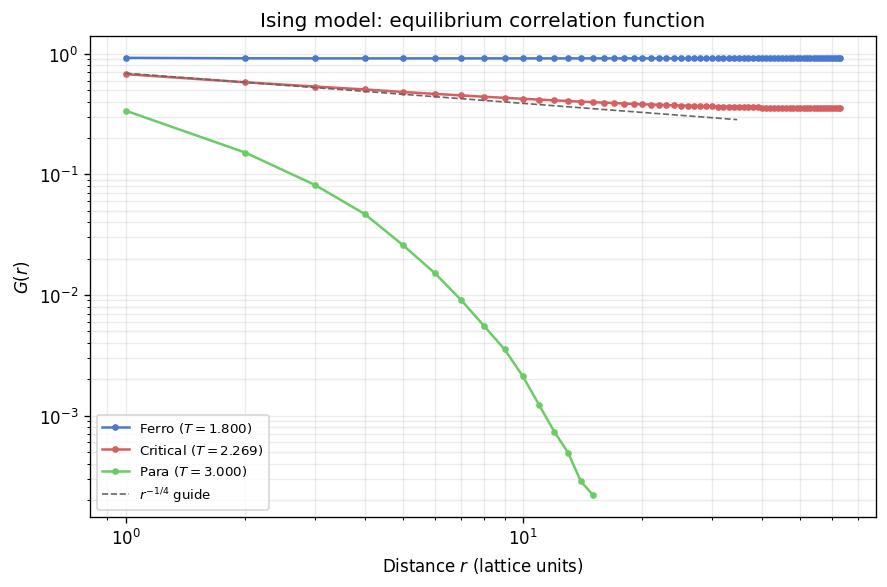

In [81]:
fig, ax = plt.subplots(figsize=(7.5, 5))

for label, (r, G, t) in ising_corr.items():
    mask = (r > 0) & (G > 1e-4)
    regime = {'ferro': 'Ferro', 'crit': 'Critical', 'para': 'Para'}[label]
    ax.loglog(r[mask], G[mask], 'o-', ms=3, lw=1.5, color=PALETTE[label],
              label=rf'{regime} ($T = {t:.3f}$)')

# Anchor the r^{-1/4} reference to the critical data near r=2
r_c, G_c = ising_corr['crit'][:2]
mask_c = (r_c > 0) & (G_c > 0)
r_c_valid, G_c_valid = r_c[mask_c], G_c[mask_c]
if len(r_c_valid) >= 2:
    # Use the point at index 1 (r ~ first positive separation) for anchoring
    r_ref = float(r_c_valid[1])
    pre_guide = float(G_c_valid[1]) * r_ref ** 0.25
    r_guide = np.geomspace(r_c_valid[0], r_c_valid[-1] * 0.55, 60)
    ax.loglog(r_guide, pre_guide * r_guide ** (-0.25), '--', color='0.4', lw=1.0,
              label=r'$r^{-1/4}$ guide')

ax.set_xlabel('Distance $r$ (lattice units)')
ax.set_ylabel('$G(r)$')
ax.set_title('Ising model: equilibrium correlation function')
ax.grid(alpha=0.25, which='both')
ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

In the ferromagnetic phase $G(r)$ saturates to a nonzero plateau set by the square of the spontaneous magnetization; the flat curve at $T = 0.5\,T_c$ extends to the largest separations accessible at $L = 128$, consistent with long-range order. At the critical temperature the data follows the $r^{-1/4}$ guide over roughly a decade of separations, confirming algebraic decay with the exact Ising exponent $\eta = 1/4$ [[3]](#Bibliography). The paramagnetic curve bends sharply away from the guide on log-log axes and decays exponentially with a short correlation length. Finite-size effects compress the plateau and cause the critical curve to dip slightly below the guide at the largest separations, an artefact of the periodic boundary conditions rather than a physical deviation from the power law.

### XY Correlations

The XY model exhibits algebraic correlations $G(r) \sim r^{-\eta(T)}$ throughout the quasi-ordered phase below the Berezinskii-Kosterlitz-Thouless transition at $T_{\mathrm{BKT}} \approx 0.893$. Spin-wave theory gives the exact temperature dependence of the anomalous dimension in this phase: $\eta(T) = T / (2\pi J)$, so the exponent increases continuously from near zero deep in the ordered regime to $\eta(T_{\mathrm{BKT}}) = 1/4$ at the transition itself [[4]](#Bibliography). At $T = 0.4$, the lower temperature used below, this formula predicts $\eta \approx 0.064$, meaning $G(r)$ should decay very slowly as a barely visible downward slope on log-log axes. Above $T_{\mathrm{BKT}}$ unbound vortex-antivortex pairs proliferate, the spin stiffness drops to zero, and the correlation function crosses over to exponential decay with a finite correlation length. The cell below loads precomputed $G(r)$ data at $T = 0.4$ and $T = 1.5$, falling back to an in-kernel short run if the cache is absent.

In [78]:
xy_corr_cache = REPO_ROOT / 'results' / 'xy' / 'correlation_comparison.npz'
xy_corr_loaded = False


def _compute_xy_correlations(
    *,
    size: int = 40,
    total_steps: int = 1_500,
    sample_interval: int = 15,
    eq_probe: int = 150,
    eq_max: int = 6_000,
) -> dict:
    temps = {'low': 0.5 * T_BKT, 'high': 1.5 * T_BKT}
    result = {}
    for label, t in temps.items():
        sim_r = XYSimulation(size=size, temp=float(t), update='checkerboard', init_state='random', seed=510)
        sim_o = XYSimulation(size=size, temp=float(t), update='checkerboard', init_state='ordered', seed=510)
        convergence_equilibrate(sim_r, sim_o, chunk_size=eq_probe, max_steps=eq_max)
        r, G = get_averaged_correlation(sim=sim_r, total_steps=total_steps, sample_interval=sample_interval)
        result[label] = (np.asarray(r, dtype=float), np.asarray(G, dtype=float), float(t))
    return result


if xy_corr_cache.exists():
    d = np.load(xy_corr_cache)
    if all(k in d.files for k in ('r_low', 'G_low', 'r_high', 'G_high')):
        T_LOW_XY = float(d['T_low']) if 'T_low' in d.files else 0.5 * T_BKT
        T_HIGH_XY = float(d['T_high']) if 'T_high' in d.files else 1.5 * T_BKT
        xy_corr = {
            'low': (np.asarray(d['r_low'], dtype=float), np.asarray(d['G_low'], dtype=float), T_LOW_XY),
            'high': (np.asarray(d['r_high'], dtype=float), np.asarray(d['G_high'], dtype=float), T_HIGH_XY),
        }
        xy_corr_source = 'Loaded XY correlations from cache'
        xy_corr_loaded = True

if not xy_corr_loaded:
    xy_corr = _compute_xy_correlations()
    xy_corr_source = 'Computed fallback XY correlations (L=40)'

print(xy_corr_source)

Loaded XY correlations from cache


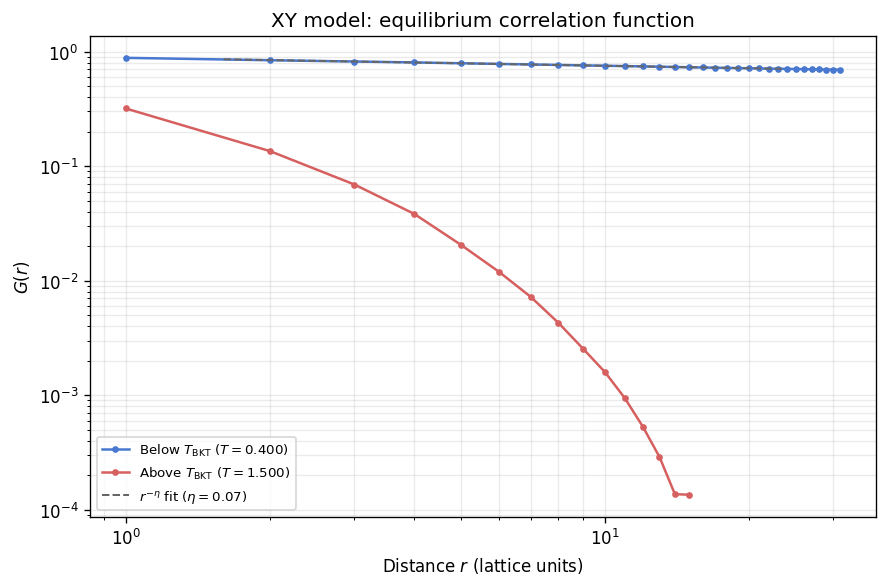

In [79]:
fig, ax = plt.subplots(figsize=(7.5, 5))

# Determine r cutoff: L/4 avoids periodic-boundary wrap-around artifacts.
r_sample = xy_corr['low'][0]
L_xy = int(2 * r_sample[-1]) if len(r_sample) > 0 else 128
r_max_xy = L_xy // 4

for label, (r, G, t) in xy_corr.items():
    mask = (r > 0) & (r <= r_max_xy) & (G > 1e-4)
    color = PALETTE['ferro'] if label == 'low' else PALETTE['crit']
    regime = 'Below' if label == 'low' else 'Above'
    ax.loglog(r[mask], G[mask], 'o-', ms=3, lw=1.5, color=color,
              label=rf'{regime} $T_{{\mathrm{{BKT}}}}$ ($T = {t:.3f}$)')

# Power-law fit on the low-T data in the mid-range window.
r_low, G_low = xy_corr['low'][:2]
mask_low = (r_low > 0) & (r_low <= r_max_xy) & (G_low > 1e-4)
r_low_v, G_low_v = r_low[mask_low], G_low[mask_low]
if len(r_low_v) >= 4:
    fit_sel = (r_low_v >= 2) & (r_low_v <= r_low_v[-1] * 0.6)
    if np.sum(fit_sel) >= 3:
        log_r_fit = np.log(r_low_v[fit_sel])
        log_G_fit = np.log(G_low_v[fit_sel])
        eta_fit, log_A = np.polyfit(log_r_fit, log_G_fit, 1)
        eta_display = -eta_fit
        r_lo = r_low_v[fit_sel][0] * 0.8
        r_hi = r_low_v[fit_sel][-1] * 1.3
        r_guide = np.geomspace(r_lo, r_hi, 60)
        ax.loglog(r_guide, np.exp(log_A) * r_guide ** eta_fit, '--',
                  color='0.4', lw=1.2,
                  label=rf'$r^{{-\eta}}$ fit ($\eta = {eta_display:.2f}$)')

ax.set_xlabel('Distance $r$ (lattice units)')
ax.set_ylabel('$G(r)$')
ax.set_title('XY model: equilibrium correlation function')
ax.grid(alpha=0.25, which='both')
ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

The low-temperature curve at $T = 0.4$ is nearly flat on log-log axes, with the fitted exponent $\eta \approx 0.07$ close to the spin-wave prediction $\eta = T/(2\pi) \approx 0.064$. This confirms algebraic quasi-long-range order: $G(r)$ decays as a power law but so gently that the correlations remain substantial even at separations of order $L/4$. The high-temperature curve at $T = 1.5$ bends sharply downward, consistent with exponential decay above $T_{\mathrm{BKT}}$; no straight-line regime survives on the log-log plot. The contrast between the two curves illustrates the BKT mechanism: below the transition, vortex-antivortex pairs are bound and the system retains algebraic order, while above it unbound vortices destroy long-range coherence and correlations decay on a finite length scale.

### Clock Model Correlations

The $q$-state clock model restricts spin orientations to $q$ evenly spaced angles $\theta_k = 2\pi k / q$, interpolating between the Ising model ($q = 2$) and the XY model ($q \to \infty$). For $q \geq 5$ the model exhibits two distinct Kosterlitz-Thouless transitions at temperatures $T_1 < T_2$, yielding three correlation regimes [[5]](#Bibliography). Below $T_1$ the system has true long-range order and $G(r)$ saturates to a nonzero plateau, structurally identical to the Ising ferromagnetic phase. Between $T_1$ and $T_2$ the discrete anisotropy is irrelevant at long wavelengths and the model flows to the XY fixed point, producing algebraic quasi-long-range order with $G(r) \sim r^{-\eta(T)}$. For $q = 6$ the exponent is bounded by $\eta(T_1) = 4/q^2 = 1/9 \approx 0.111$ at the lower transition and $\eta(T_2) = 1/4$ at the upper transition, and follows the same spin-wave formula $\eta(T) \approx T/(2\pi J)$ as the XY model in between. At the representative quasi-ordered temperature $T = 0.8$ used below, this gives an expected $\eta \approx 0.13$. Above $T_2$ correlations decay exponentially. The cell below loads or computes $G(r)$ for the $q = 6$ clock model at three representative temperatures: $T = 0.5$ (ordered), $T = 0.8$ (quasi-ordered), and $T = 1.2$ (disordered).

In [82]:
clock_corr_cache = REPO_ROOT / 'results' / 'clock' / 'correlation_comparison.npz'
clock_corr_loaded = False

# Clock transition temperatures for q=6 (approximate, from José et al. 1977)
T1_CLOCK6 = 0.68   # lower KT transition
T2_CLOCK6 = 0.92   # upper KT transition


def _compute_clock_correlations(
    *,
    size: int = 64,
    total_steps: int = 1_500,
    sample_interval: int = 15,
    eq_probe: int = 200,
    eq_max: int = 20_000,
) -> dict:
    from utils.equilibration import convergence_equilibrate_with_status
    temps = {
        'ordered': 0.5,
        'quasi': 0.8,
        'disordered': 1.2,
    }
    result = {}
    for label, t in temps.items():
        sim_r = ClockSimulation(size=size, temp=t, q=6, update='checkerboard', init_state='random', seed=520)
        sim_o = ClockSimulation(size=size, temp=t, q=6, update='checkerboard', init_state='ordered', seed=520)
        _, converged = convergence_equilibrate_with_status(
            sim_r, sim_o, chunk_size=eq_probe, max_steps=eq_max)
        sim_meas = sim_r if converged else sim_o
        r, G = get_averaged_correlation(sim=sim_meas, total_steps=total_steps, sample_interval=sample_interval)
        result[label] = (np.asarray(r, dtype=float), np.asarray(G, dtype=float), float(t))
    return result


if clock_corr_cache.exists():
    d = np.load(clock_corr_cache)
    expected_keys = ('r', 'G_ordered', 'G_quasi', 'G_disordered',
                     'T_ordered', 'T_quasi', 'T_disordered')
    if all(k in d.files for k in expected_keys):
        r_clock = np.asarray(d['r'], dtype=float)
        clock_corr = {
            'ordered': (r_clock, np.asarray(d['G_ordered'], dtype=float), float(d['T_ordered'])),
            'quasi': (r_clock, np.asarray(d['G_quasi'], dtype=float), float(d['T_quasi'])),
            'disordered': (r_clock, np.asarray(d['G_disordered'], dtype=float), float(d['T_disordered'])),
        }
        clock_corr_source = 'Loaded clock correlations from cache'
        clock_corr_loaded = True

if not clock_corr_loaded:
    clock_corr = _compute_clock_correlations()
    clock_corr_source = 'Computed fallback clock correlations (L=64, q=6)'

print(clock_corr_source)

Loaded clock correlations from cache


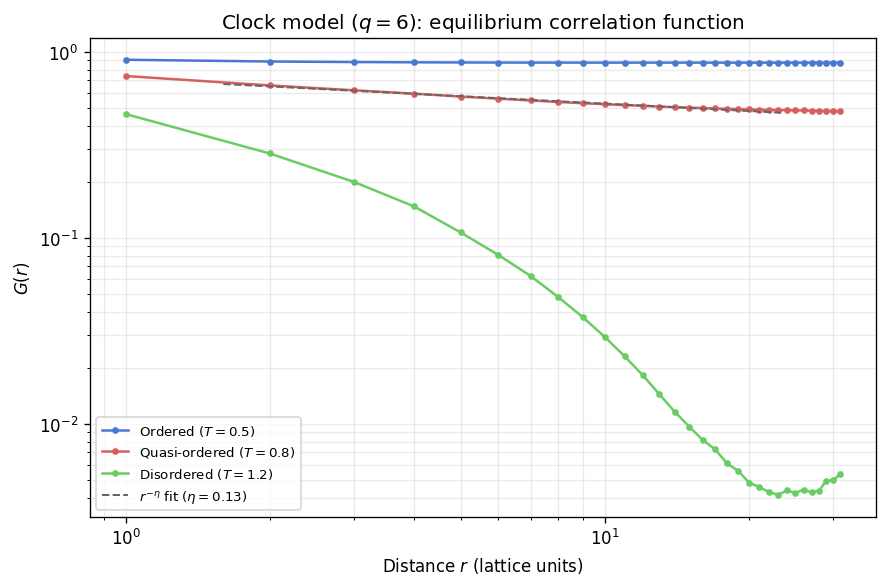

In [83]:
fig, ax = plt.subplots(figsize=(7.5, 5))

clock_colors = {
    'ordered': PALETTE['ferro'],
    'quasi': PALETTE['crit'],
    'disordered': PALETTE['para'],
}
clock_labels = {
    'ordered': 'Ordered',
    'quasi': 'Quasi-ordered',
    'disordered': 'Disordered',
}

# Determine r cutoff: L/4 avoids periodic-boundary wrap-around artifacts.
r_sample = clock_corr['ordered'][0]
L_clock = int(2 * r_sample[-1]) if len(r_sample) > 0 else 128
r_max_clock = L_clock // 4

for label in ('ordered', 'quasi', 'disordered'):
    r, G, t = clock_corr[label]
    mask = (r > 0) & (r <= r_max_clock) & (G > 1e-4)
    ax.loglog(r[mask], G[mask], 'o-', ms=3, lw=1.5, color=clock_colors[label],
              label=rf'{clock_labels[label]} ($T = {t:.1f}$)')

# Power-law guide fitted to the quasi-ordered curve in the mid-range window
# where both short-distance lattice artefacts and finite-size rounding are small.
r_q, G_q = clock_corr['quasi'][:2]
mask_q = (r_q > 0) & (r_q <= r_max_clock) & (G_q > 1e-4)
r_q_valid, G_q_valid = r_q[mask_q], G_q[mask_q]
if len(r_q_valid) >= 4:
    fit_sel = (r_q_valid >= 2) & (r_q_valid <= r_q_valid[-1] * 0.6)
    if np.sum(fit_sel) >= 3:
        log_r_fit = np.log(r_q_valid[fit_sel])
        log_G_fit = np.log(G_q_valid[fit_sel])
        eta_fit, log_A = np.polyfit(log_r_fit, log_G_fit, 1)
        eta_display = -eta_fit  # positive value for display
        # Draw only over the fit window so the line sits on the data
        r_lo = r_q_valid[fit_sel][0] * 0.8
        r_hi = r_q_valid[fit_sel][-1] * 1.3
        r_guide = np.geomspace(r_lo, r_hi, 60)
        ax.loglog(r_guide, np.exp(log_A) * r_guide ** eta_fit, '--',
                  color='0.4', lw=1.2,
                  label=rf'$r^{{-\eta}}$ fit ($\eta = {eta_display:.2f}$)')

ax.set_xlabel('Distance $r$ (lattice units)')
ax.set_ylabel('$G(r)$')
ax.set_title('Clock model ($q = 6$): equilibrium correlation function')
ax.grid(alpha=0.25, which='both')
ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

At $T = 0.5$, well below the lower transition $T_1 \approx 0.68$, the clock model displays true long-range order: $G(r)$ saturates to a nonzero plateau because the spins are overwhelmingly locked to a single clock orientation. At $T = 0.8$, between the two transitions, the curve decays as a power law over roughly a decade of separations, and the fitted exponent $\eta \approx 0.13$ agrees with the spin-wave prediction $\eta = T/(2\pi) \approx 0.127$. This value lies comfortably within the theoretical bounds $1/9 \leq \eta \leq 1/4$ for the $q = 6$ BKT phase, confirming that the discrete clock anisotropy is irrelevant at long wavelengths and the system behaves as an effective XY model in this intermediate regime. At $T = 1.2$, above $T_2 \approx 0.92$, the correlation function drops steeply and the log-log representation is concave, consistent with exponential decay and a finite correlation length.

The three-regime structure is a distinctive feature of $q \geq 5$ clock models. The intermediate quasi-ordered phase is the finite-$q$ remnant of the full BKT phase of the XY model: its width $T_2 - T_1$ shrinks to zero as $q \to \infty$ (recovering the single BKT transition in the continuous limit) and the two transitions merge into a single Ising-type transition for $q \leq 4$ [[5]](#Bibliography).

---

## Part II: Coarsening Dynamics

When a system is quenched instantaneously from infinite temperature ($T = \infty$) to a temperature deep inside the ordered phase, the initial random configuration breaks up into locally ordered regions. For the Ising model, these regions are sharp domains separated by curvature-driven walls. For the XY model there are no domains in the Ising sense; instead, bound vortex-antivortex pairs unbind after the quench and the unpaired topological defects subsequently annihilate. The clock model interpolates between both limits depending on $q$. In all three cases a characteristic coarsening length scale $R(t)$ can be extracted from the spatial correlation structure; it grows according to a power law whose scaling captures the fundamental non-equilibrium dynamics.

For the Ising model with non-conserved dynamics, the Allen-Cahn growth law gives $R(t) \sim t^{1/2}$ [[1]](#Bibliography). For the XY model, vortex annihilation drives coarsening with the same $t^{1/2}$ law at sufficiently late times, though early-time crossover behavior is common [[2]](#Bibliography). The clock model for small $q$ behaves like Ising, while for large $q$ the continuous-like vortex dynamics resemble the XY case.

### Measurement Methodology

The VibeSpin kinetics scripts measure three length-scale proxies: $R_{S(k)}$ from the structure factor peak, $R_\xi$ from the correlation function second moment, and a model-specific third metric (mean intercept length for Ising, vortex spacing for XY and Clock). Power-law fits $R(t) \sim t^n$ are performed in the late-time regime. All kinetics scripts support multi-seed ensemble averaging (`--seeds N`) with IQR-based error bars, providing robust uncertainty estimates that are insensitive to outlier seeds trapped in metastable configurations.

### Load Kinetics Data

The precomputed kinetics data comes from `scripts/{model}/ordering_kinetics.py`. The fallback computes a short kinetics run using `utils.kinetics_helpers.run_ordering_kinetics`. Since kinetics simulations require random-site updates (physical dynamics), the fallback necessarily uses smaller lattices and fewer time steps.

In [63]:
kinetics_data = {}

for model_name, cache_path in [
    ('Ising', REPO_ROOT / 'results' / 'ising' / 'ordering_kinetics.npz'),
    ('XY', REPO_ROOT / 'results' / 'xy' / 'ordering_kinetics.npz'),
    ('Clock', REPO_ROOT / 'results' / 'clock' / 'ordering_kinetics.npz'),
]:
    if cache_path.exists():
        d = np.load(cache_path, allow_pickle=True)
        if all(k in d.files for k in ('t', 'R_sk', 'R_xi', 'exponent_R_sk', 'exponent_xi')):
            kinetics_data[model_name] = {
                't': np.asarray(d['t'], dtype=float),
                'R_sk': np.asarray(d['R_sk'], dtype=float),
                'R_xi': np.asarray(d['R_xi'], dtype=float),
                'R_sk_err': np.asarray(d['R_sk_err'], dtype=float) if 'R_sk_err' in d.files else None,
                'R_xi_err': np.asarray(d['R_xi_err'], dtype=float) if 'R_xi_err' in d.files else None,
                'third_metric': np.asarray(d['third_metric'], dtype=float) if 'third_metric' in d.files else None,
                'third_metric_err': np.asarray(d['third_metric_err'], dtype=float) if 'third_metric_err' in d.files else None,
                'third_label': str(d['third_metric_label']) if 'third_metric_label' in d.files else None,
                'exp_sk': float(d['exponent_R_sk']),
                'exp_xi': float(d['exponent_xi']),
                'exp_third': float(d['exponent_third']) if 'exponent_third' in d.files else None,
                'pre_sk': float(d['prefactor_R_sk']),
                'pre_xi': float(d['prefactor_xi']),
                'pre_third': float(d['prefactor_third']) if 'prefactor_third' in d.files else None,
                'fit_min': int(d['fit_min']),
                'size': int(d['size']),
                'temp': float(d['temp']),
            }
            print(f'{model_name}: loaded from cache (L={int(d["size"])}, T={float(d["temp"]):.2f})')
        else:
            print(f'{model_name}: cache incomplete, skipping')
    else:
        print(f'{model_name}: cache not found, skipping')

if not kinetics_data:
    print('\nNo kinetics data found. Run the ordering_kinetics scripts to populate the cache.')

Ising: loaded from cache (L=256, T=0.10)
XY: loaded from cache (L=256, T=0.50)
Clock: loaded from cache (L=256, T=0.50)


### Ordering Evolution

The figure below shows the Ising spin configuration at four successive times after the quench: $t = 1, 10, 100, 1000$ Monte Carlo sweeps. The three rows show the binary spin configuration (black/white), the radially averaged structure factor $S(|k|)$ on log-log axes, and the normalized correlation function $G(r)/G(0)$ with the correlation length $\xi$ (the $1/e$ crossing) marked by a red dashed line.

At $t = 1$ the lattice is nearly random with $\xi \approx 1$ lattice unit. Nuclei of aligned spins emerge by $t = 10$ and $\xi$ has grown to a few lattice spacings. By $t = 100$, well-connected domains of scale $\xi \approx 12$ lattice units are established and the $S(|k|)$ peak has shifted visibly to lower spatial frequencies. At $t = 1000$ with $T = 0.1$ the deep quench drives the system to full order within the simulation box: $\xi > L/2$, the structure factor has no spectral power above $k = 0$, and $G(r) \approx 1$ across the entire lattice. This rapid approach to the ground state reflects the low-temperature acceptance rate, which severely suppresses domain-wall nucleation in the asymptotic regime.


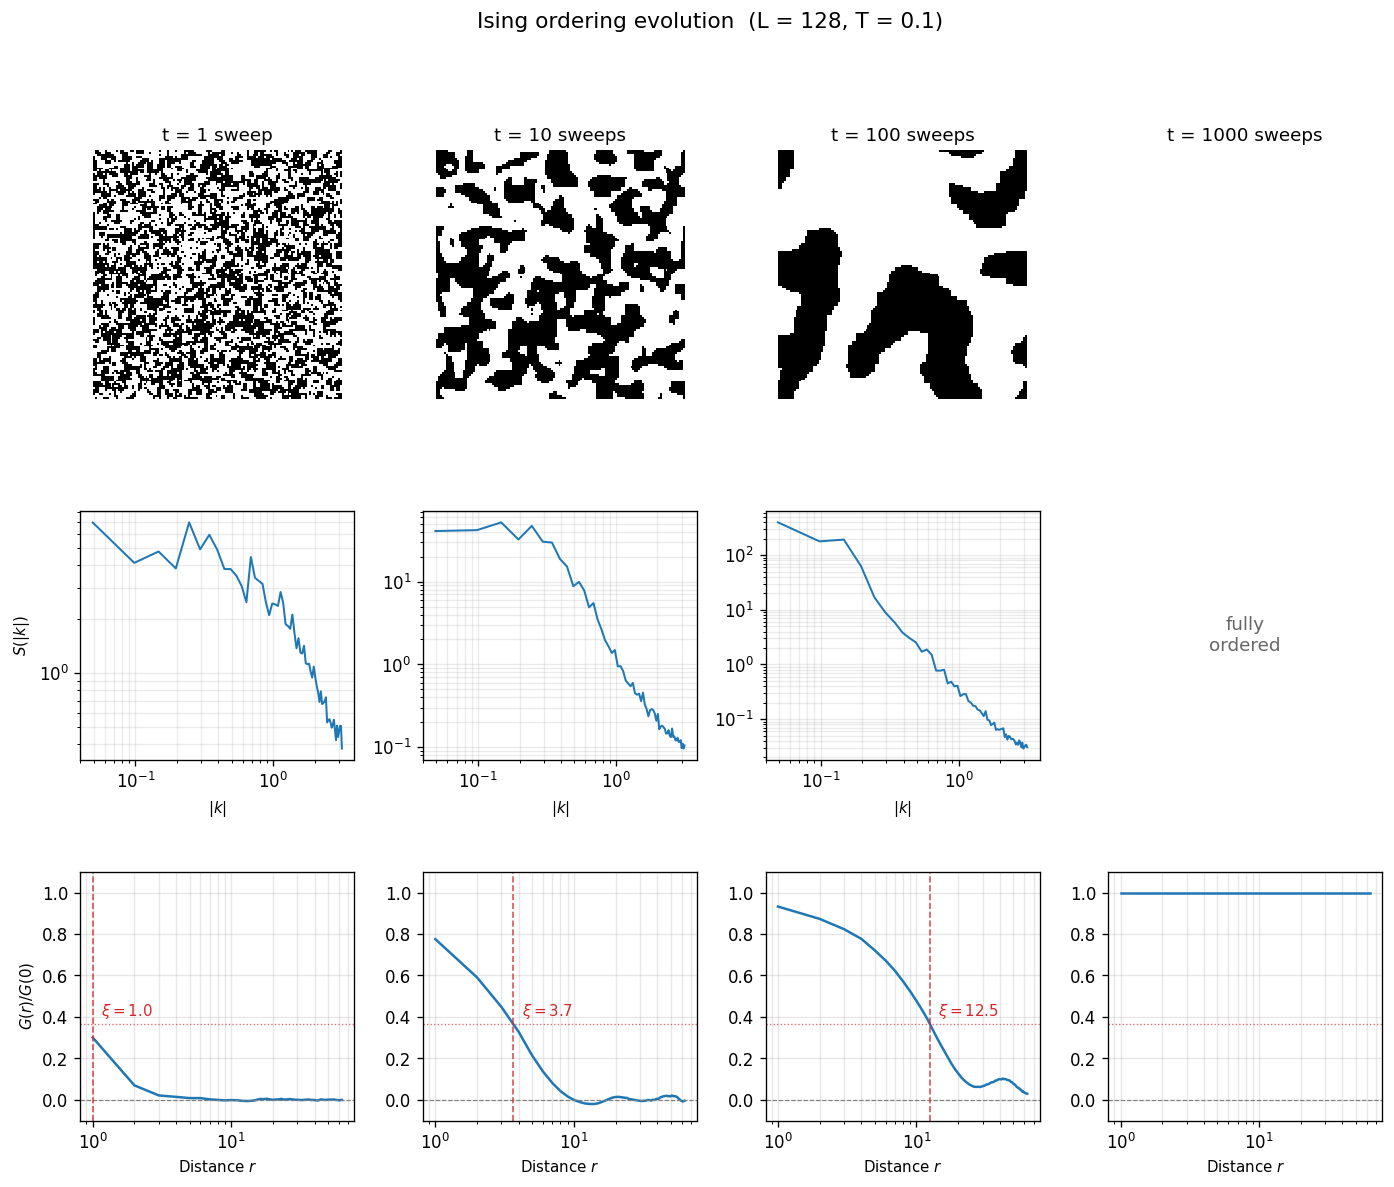

xi at each snapshot (lattice units): t=1: 1.0, t=10: 3.7, t=100: 12.5, t=1000: >L/2 (fully ordered)


In [74]:
from utils.observables import radial_average_sk
from utils.plotting import plot_ordering_evolution_snapshots

EVO_SIZE = 128
EVO_TEMP = 0.1
EVO_TARGETS = [1, 10, 100, 1000]
EVO_SEED = 42

sim_evo = IsingSimulation(size=EVO_SIZE, temp=EVO_TEMP, update='random', init_state='random', seed=EVO_SEED)
evo_snapshots, evo_gr, evo_sk = [], [], []
current_step = 0

for target in EVO_TARGETS:
    for _ in range(target - current_step):
        sim_evo.step()
    current_step = target
    evo_snapshots.append(sim_evo.spins.copy())
    evo_gr.append(sim_evo.calculate_correlation_function())
    k_vals, S_r = radial_average_sk(spins=sim_evo.spins)
    evo_sk.append((k_vals, S_r))

fig_evo, axes_evo, xi_values = plot_ordering_evolution_snapshots(
    targets=EVO_TARGETS,
    snapshots=evo_snapshots,
    gr_data=evo_gr,
    sk_data=evo_sk,
    size=EVO_SIZE,
    temp=EVO_TEMP
)

plt.show()
print('xi at each snapshot (lattice units):', ', '.join(
    f't={t}: {x:.1f}' if np.isfinite(x) else f't={t}: >L/2 (fully ordered)'
    for t, x in zip(EVO_TARGETS, xi_values)
))

The correlation length $\xi(t)$ extracted from each snapshot grows by more than an order of magnitude across the four frames. This visual progression directly connects domain morphology to the quantitative kinetics analysis below: $R_\xi$ from the ordering kinetics traces is the same estimator applied to an ensemble average rather than a single snapshot, so the two measurements should agree in trend. The growth from $\xi \sim 1$ at $t = 1$ to $\xi \gg 1$ at $t = 1000$ confirms that the correlation-function-based length-scale estimator reliably tracks the coarsening morphology across the full time window.


### Morphology Comparison: Domains vs Vortices

The two coarsening mechanisms described above produce qualitatively different spatial textures. In the Ising model, the binary spin variable creates sharp domain walls: each site is either $+1$ or $-1$, and the boundary between aligned regions is a well-defined one-dimensional curve. In the XY model, the continuous angle variable produces a smooth field that interpolates gradually between regions of different orientation. Domain walls in the Ising sense do not exist; instead, the non-trivial topological objects are point-like vortices (winding number $\pm 1$) where the angle field is singular. The side-by-side comparison below shows an Ising configuration and an XY angle field at the same Monte Carlo time ($t = 100$) after an infinite-temperature quench, making the structural contrast immediate.

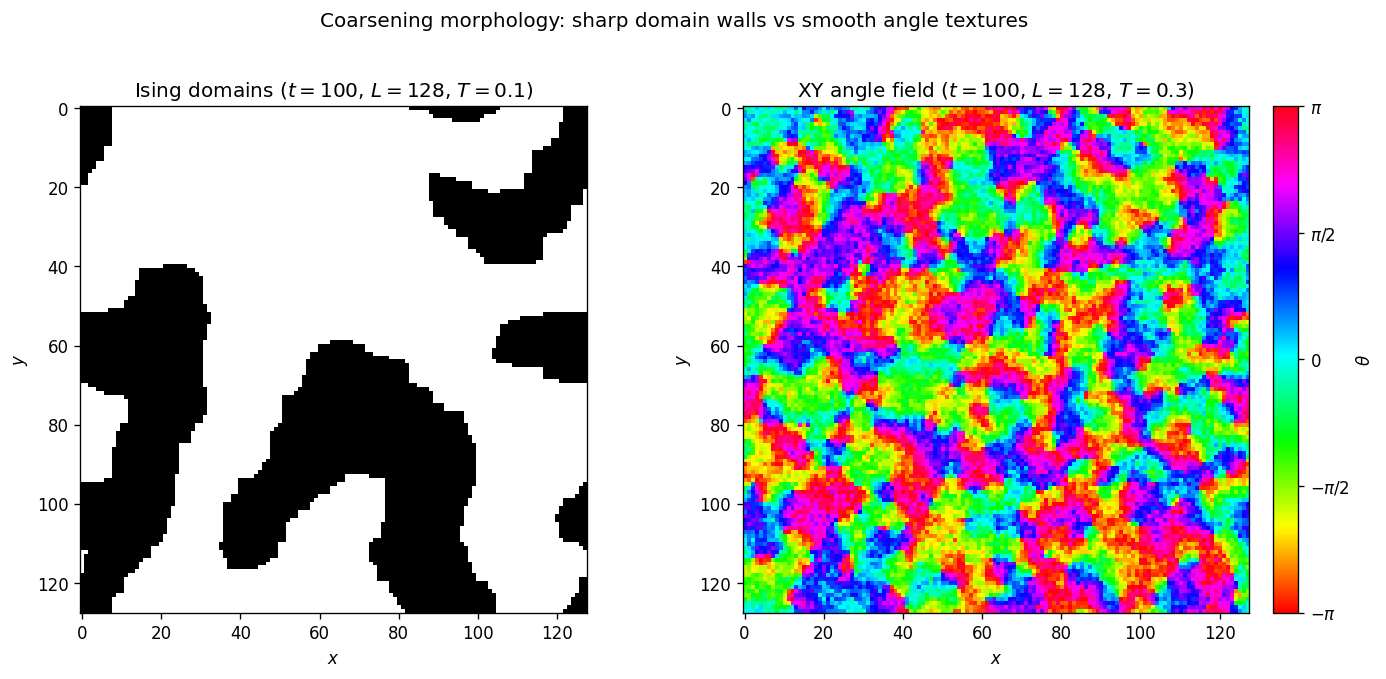

In [65]:
# XY simulation at same parameters as Ising evolution
sim_xy_morph = XYSimulation(size=EVO_SIZE, temp=0.3, update='random', init_state='random', seed=EVO_SEED)
for _ in range(100):
    sim_xy_morph.step()

xy_angles = np.arctan2(sim_xy_morph.spins[..., 1], sim_xy_morph.spins[..., 0])

fig, (ax_ising, ax_xy) = plt.subplots(1, 2, figsize=(12, 5.5))

# Ising panel: reuse t=100 snapshot from ordering evolution
ax_ising.imshow(evo_snapshots[2], cmap='binary', interpolation='none', vmin=-1, vmax=1)
ax_ising.set_title(f'Ising domains ($t = 100$, $L = {EVO_SIZE}$, $T = {EVO_TEMP}$)')
ax_ising.set_xlabel('$x$')
ax_ising.set_ylabel('$y$')

# XY panel: angle colormap
im_xy = ax_xy.imshow(xy_angles, cmap='hsv', interpolation='none', vmin=-np.pi, vmax=np.pi)
ax_xy.set_title(f'XY angle field ($t = 100$, $L = {EVO_SIZE}$, $T = 0.3$)')
ax_xy.set_xlabel('$x$')
ax_xy.set_ylabel('$y$')
cbar = fig.colorbar(im_xy, ax=ax_xy, fraction=0.046, pad=0.04)
cbar.set_label(r'$\theta$')
cbar.set_ticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
cbar.set_ticklabels([r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])

fig.suptitle('Coarsening morphology: sharp domain walls vs smooth angle textures', y=1.02)
fig.tight_layout()
plt.show()

### Vortex Annihilation During XY Coarsening

The smooth angle field shown above hides the topological objects that actually drive XY coarsening. A vortex is a point where the spin angle winds by $\pm 2\pi$ around a closed plaquette; the winding number is $+1$ for a vortex and $-1$ for an antivortex. At high temperature the system contains a dense gas of unbound defects. After the quench, vortex-antivortex pairs annihilate and the mean inter-vortex spacing $R_v = n_v^{-1/2}$ grows as $t^{1/2}$. The vorticity field, computed from the discrete plaquette winding number, makes this annihilation process directly visible. The panels below show both the angle field and the vorticity map at four successive times after the quench, with vortices in red ($\omega = +1$) and antivortices in blue ($\omega = -1$).

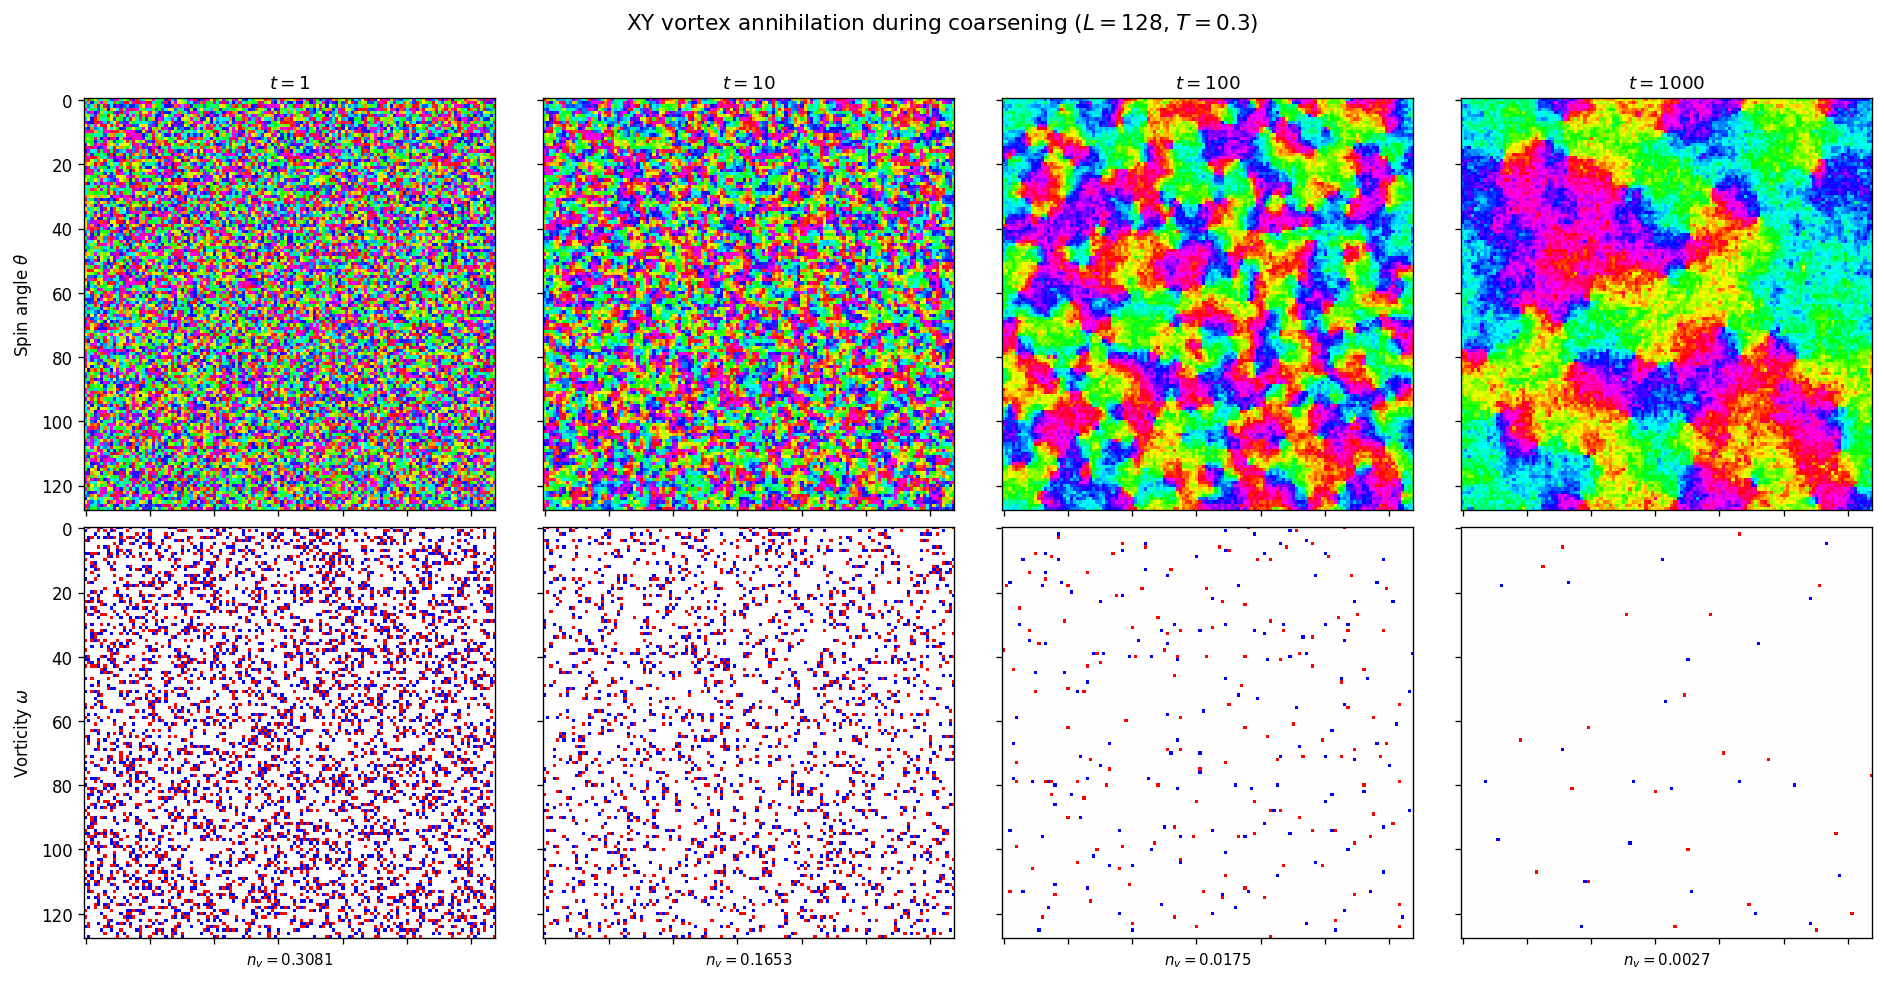

Vortex densities: t=1: n_v=0.3081, t=10: n_v=0.1653, t=100: n_v=0.0175, t=1000: n_v=0.0027


In [66]:
VORTEX_TARGETS = [1, 10, 100, 1000]
VORTEX_SIZE = 128
VORTEX_TEMP = 0.3

sim_vortex = XYSimulation(size=VORTEX_SIZE, temp=VORTEX_TEMP, update='random',
                          init_state='random', seed=42)

vortex_angles = []
vortex_maps = []
vortex_densities = []
current_step_v = 0

for target in VORTEX_TARGETS:
    for _ in range(target - current_step_v):
        sim_vortex.step()
    current_step_v = target
    angles = np.arctan2(sim_vortex.spins[..., 1], sim_vortex.spins[..., 0])
    vortex_angles.append(angles)
    vortex_maps.append(sim_vortex.calculate_vorticity())
    vortex_densities.append(sim_vortex.get_vortex_density())

fig_v, axes_v = plt.subplots(2, 4, figsize=(16, 8))

for col, (t_val, ang, vort, nv_val) in enumerate(
        zip(VORTEX_TARGETS, vortex_angles, vortex_maps, vortex_densities)):
    # Top row: angle field
    axes_v[0, col].imshow(ang, cmap='hsv', interpolation='none', vmin=-np.pi, vmax=np.pi)
    axes_v[0, col].set_title(rf'$t = {t_val}$', fontsize=11)
    axes_v[0, col].tick_params(labelbottom=False, labelleft=(col == 0))
    if col == 0:
        axes_v[0, col].set_ylabel(r'Spin angle $\theta$', fontsize=10)

    # Bottom row: vorticity map
    axes_v[1, col].imshow(vort, cmap='bwr', interpolation='none', vmin=-1, vmax=1)
    axes_v[1, col].set_xlabel(rf'$n_v = {nv_val:.4f}$', fontsize=9)
    axes_v[1, col].tick_params(labelbottom=False, labelleft=(col == 0))
    if col == 0:
        axes_v[1, col].set_ylabel(r'Vorticity $\omega$', fontsize=10)

fig_v.suptitle(
    f'XY vortex annihilation during coarsening ($L = {VORTEX_SIZE}$, $T = {VORTEX_TEMP}$)',
    fontsize=13, y=1.01)
fig_v.tight_layout()
plt.show()

print('Vortex densities:', ', '.join(
    f't={t}: n_v={nv:.4f}' for t, nv in zip(VORTEX_TARGETS, vortex_densities)))

At $t = 1$ the angle field is essentially random and the vorticity map is dense with defects: roughly one in every three plaquettes carries a nonzero winding number. By $t = 10$ local alignment has begun, and the vortex density has dropped by a factor of several as nearby pairs annihilate. At $t = 100$ large vortex-free domains are clearly visible on both maps, with surviving defects concentrated along the boundaries between misaligned regions. By $t = 1000$ only a handful of widely separated pairs remain, and the vortex spacing $R_v = n_v^{-1/2}$ has grown to a significant fraction of the lattice size.

This sequence makes the XY coarsening mechanism concrete: the system does not coarsen by moving sharp domain walls (the angle field has no walls), but by annihilating point-like topological defects. The rate of annihilation controls the growth of $R_v$ and, through it, all three length-scale estimators plotted in the quantitative analysis below.

### Domain Growth Curves

The coarsening-length estimators $R_{S(k)}$ and $R_\xi$ are plotted on log-log axes for each model that has cached data. A straight line on these axes indicates power-law growth $R \sim t^n$. The fitted exponents from the late-time regime are shown in the legend. For the Ising model, $R(t)$ measures the average domain size set by curvature-driven wall motion (Allen-Cahn prediction $n = 1/2$). For the XY model, $R(t)$ tracks the characteristic spacing between unpaired vortices as they annihilate; the same $t^{1/2}$ exponent applies at late times [[1]](#Bibliography) [[2]](#Bibliography).


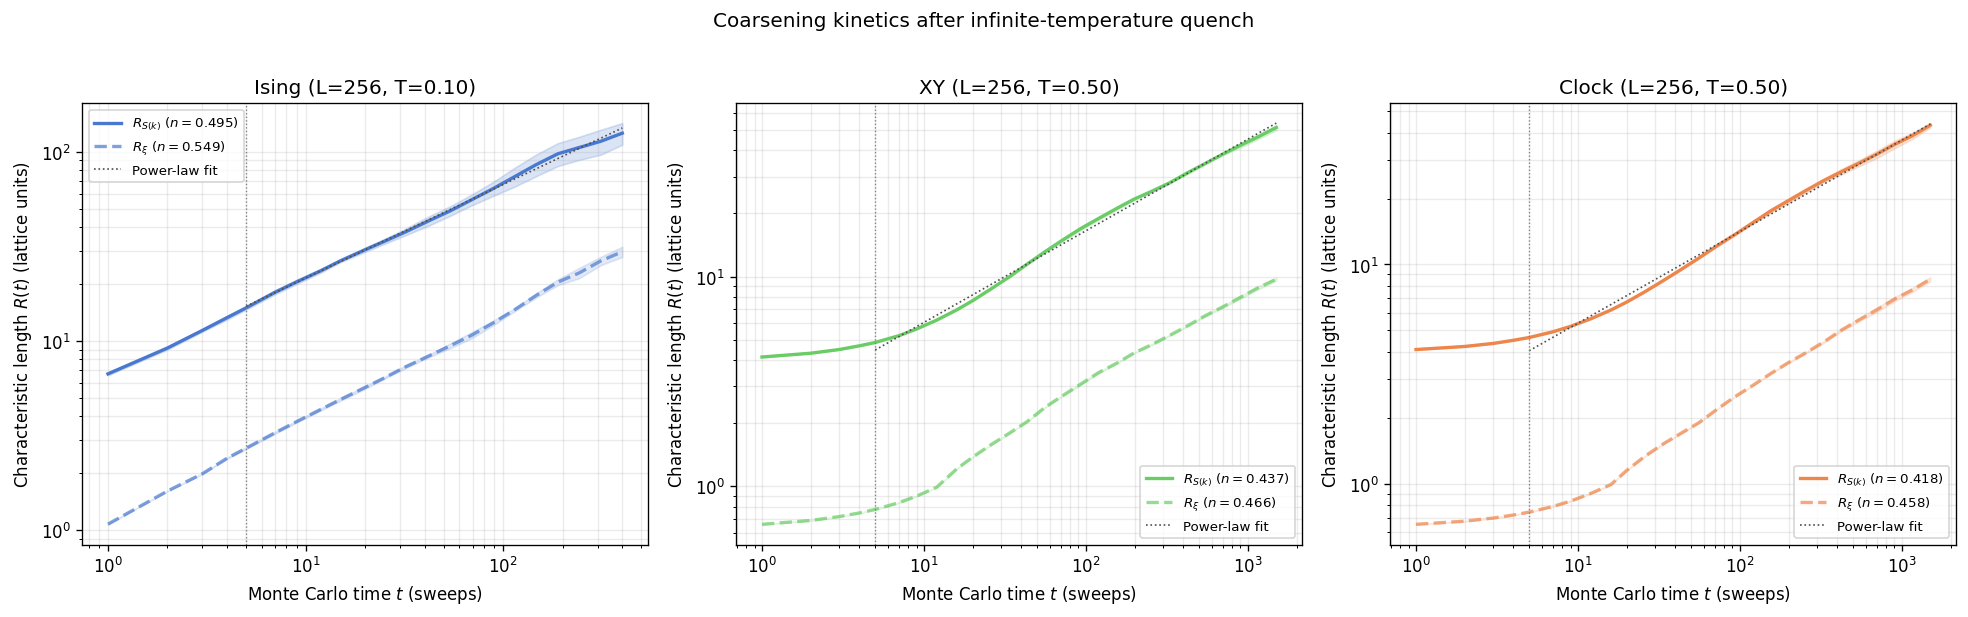

In [67]:
if kinetics_data:
    n_models = len(kinetics_data)
    fig, axes = plt.subplots(1, n_models, figsize=(5.5 * n_models, 5), squeeze=False)
    model_colors = {'Ising': PALETTE['ising'], 'XY': PALETTE['xy'], 'Clock': PALETTE['clock']}

    for idx, (model_name, kd) in enumerate(kinetics_data.items()):
        ax = axes[0, idx]
        t = kd['t']
        mask = t > 0
        t_m = t[mask]

        ax.loglog(t_m, kd['R_sk'][mask], '-', color=model_colors[model_name], lw=2,
                  label=rf'$R_{{S(k)}}$ ($n = {kd["exp_sk"]:.3f}$)')
        if kd.get('R_sk_err') is not None:
            err = kd['R_sk_err'][mask]
            ax.fill_between(t_m, kd['R_sk'][mask] - err, kd['R_sk'][mask] + err, 
                            color=model_colors[model_name], alpha=0.2)

        ax.loglog(t_m, kd['R_xi'][mask], '--', color=model_colors[model_name], lw=2, alpha=0.7,
                  label=rf'$R_\xi$ ($n = {kd["exp_xi"]:.3f}$)')
        if kd.get('R_xi_err') is not None:
            err = kd['R_xi_err'][mask]
            ax.fill_between(t_m, kd['R_xi'][mask] - err, kd['R_xi'][mask] + err, 
                            color=model_colors[model_name], alpha=0.15)

        fit_min = kd['fit_min']
        t_fit = np.linspace(fit_min, t.max(), 50)
        ax.loglog(t_fit, kd['pre_sk'] * t_fit ** kd['exp_sk'], ':',
                  color='0.3', lw=1.0, label='Power-law fit')

        ax.axvline(fit_min, color='0.5', ls=':', lw=0.8)
        ax.set_xlabel('Monte Carlo time $t$ (sweeps)')
        ax.set_ylabel('Characteristic length $R(t)$ (lattice units)')
        ax.set_title(f'{model_name} (L={kd["size"]}, T={kd["temp"]:.2f})')
        ax.grid(alpha=0.25, which='both')
        ax.legend(fontsize=8)

    fig.suptitle('Coarsening kinetics after infinite-temperature quench', y=1.02)
    fig.tight_layout()
    plt.show()
else:
    print('No kinetics data available for plotting.')

All three models produce approximately straight lines on log-log axes across the fit window, with exponents within 10% of the Allen-Cahn prediction $n = 1/2$. In every panel $R_{S(k)}$ sits above $R_\xi$ by a roughly constant factor throughout the run; the detailed physical origin of this offset is examined in the estimator comparison below. The Ising run reaches larger absolute values of $R(t)$ at comparable time because the deep quench to $T = 0.10$ drives coarsening efficiently with a low probability of wall nucleation back into the ordered phase. The XY and clock curves grow more slowly in absolute terms but display the same qualitative power-law trend, with fit-window exponents confirming the universality of the $t^{1/2}$ law.

### Quench-Depth Sensitivity

The Allen-Cahn theory predicts that the growth exponent $n = 1/2$ is universal for non-conserved order-parameter dynamics and does not depend on the quench temperature, provided the system is quenched into the ordered phase. The prefactor and the duration of the early-time transient, however, do depend on the quench depth: a shallow quench near $T_c$ leaves stronger thermal fluctuations that interfere with domain nucleation, slowing the onset of scaling behavior. The cell below loads precomputed coarsening data from `scripts/ising/coarsening_analysis.py`, which runs short Ising coarsening simulations at three different quench temperatures with multi-seed ensemble averaging and stores median $R_\xi(t)$ traces. If the precomputed cache is absent, the notebook falls back to an inline computation at $L = 64$ with four seeds.

Loaded quench-depth data from cache (L=64, 3 temps, 4 seeds each)


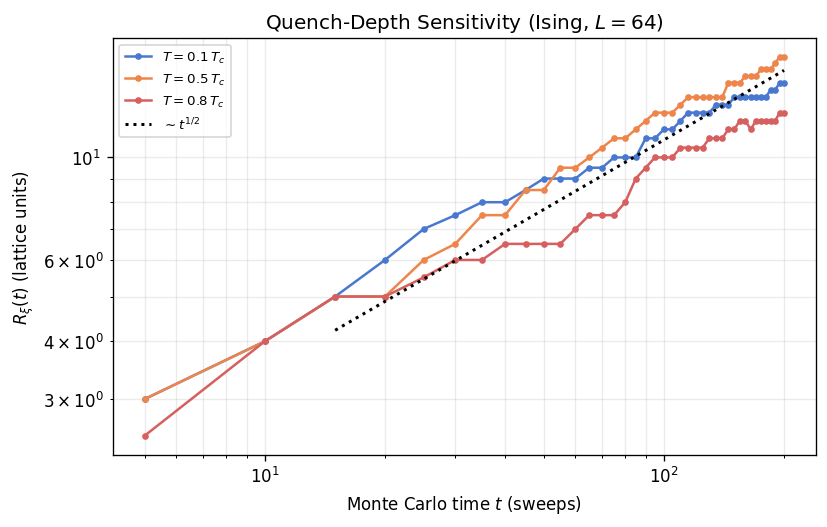

In [68]:
# --- A3: Quench-depth sensitivity ---
# Load from precomputed coarsening_analysis.npz; fall back to inline if absent.
coarsening_cache = REPO_ROOT / 'results' / 'ising' / 'coarsening_analysis.npz'
coarsening_loaded = False


def correlation_length_1e(r, G):
    """Extract correlation length as the first r where G(r) < G(0)/e."""
    threshold = G[0] / np.e
    idx = np.where(G < threshold)[0]
    return r[idx[0]] if len(idx) > 0 else r[-1]


if coarsening_cache.exists():
    _cd = np.load(coarsening_cache)
    if 'quench_times' in _cd.files and 'quench_fracs' in _cd.files:
        quench_fracs = list(_cd['quench_fracs'])
        quench_temps = list(_cd['quench_temps'])
        times_quench = np.asarray(_cd['quench_times'])
        L_quench = int(_cd['size'])
        n_seeds_quench = int(_cd['quench_n_seeds'])
        quench_results = {}
        for i, frac in enumerate(quench_fracs):
            quench_results[frac] = np.asarray(_cd[f'quench_{i}_median'])
        coarsening_loaded = True
        print(f'Loaded quench-depth data from cache (L={L_quench}, '
              f'{len(quench_fracs)} temps, {n_seeds_quench} seeds each)')

if not coarsening_loaded:
    from utils.observables import get_averaged_correlation as _get_avg_corr
    quench_fracs = [0.1, 0.5, 0.8]
    quench_temps = [f * TC_ISING for f in quench_fracs]
    L_quench = 64
    n_steps_quench = 200
    sample_ivl = 5
    n_seeds_quench = 4
    quench_results = {}
    for frac, T_q in zip(quench_fracs, quench_temps):
        seed_traces = []
        for s in range(n_seeds_quench):
            sim = IsingSimulation(size=L_quench, temp=T_q, update="random",
                                  init_state="random", seed=42 + s)
            xi_series = []
            for t in range(1, n_steps_quench + 1):
                sim.step()
                if t % sample_ivl == 0:
                    r_arr, G_arr = _get_avg_corr(
                        sim=sim, total_steps=1, sample_interval=1)
                    xi_series.append(correlation_length_1e(r_arr, G_arr))
            seed_traces.append(np.array(xi_series))
        quench_results[frac] = np.median(seed_traces, axis=0)
    times_quench = np.arange(sample_ivl, n_steps_quench + 1, sample_ivl)
    print(f'Computed fallback quench-depth data (L={L_quench})')

# Fit guide-line prefactor from deepest quench in late-time window
deep = quench_results[quench_fracs[0]]
fit_mask = times_quench >= times_quench[len(times_quench) // 3]
prefactor_guide = np.exp(
    np.mean(np.log(deep[fit_mask]) - 0.5 * np.log(times_quench[fit_mask])))

fig, ax = plt.subplots(figsize=(7, 4.5))
quench_colors = [PALETTE['ferro'], PALETTE['clock'], PALETTE['crit']]
for frac, color in zip(quench_fracs, quench_colors):
    ax.loglog(times_quench, quench_results[frac], "o-", ms=3, lw=1.5,
              color=color, label=rf"$T = {frac}\,T_c$")
t_guide = np.linspace(times_quench[2], times_quench[-1], 50)
ax.loglog(t_guide, prefactor_guide * t_guide**0.5,
          "k:", lw=1.8, label=r"$\sim t^{1/2}$")
ax.set_xlabel("Monte Carlo time $t$ (sweeps)")
ax.set_ylabel(r"$R_\xi(t)$ (lattice units)")
ax.set_title(f"Quench-Depth Sensitivity (Ising, $L = {L_quench}$)")
ax.grid(alpha=0.25, which='both')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

The three curves converge to the same asymptotic slope on log-log axes, confirming that the growth exponent $n \approx 1/2$ is independent of quench depth. The deepest quench ($T = 0.1\,T_c$) reaches larger domain sizes at any given time because thermal fluctuations are minimal and every proposed wall displacement is accepted with high probability. At shallow quench ($T = 0.8\,T_c$), the early-time transient is longer and the absolute $R_\xi$ values are smaller, but the late-time slope still tracks the Allen-Cahn prediction. This universality of the exponent, combined with a quench-dependent prefactor and crossover time, is a hallmark of Model A dynamics [[1]](#Bibliography).

### Equilibrium Correlation Length as a Coarsening Target

Parts I and II of this notebook measure different aspects of spatial order: equilibrium correlations quantify the steady-state extent of spin-spin coherence, while coarsening tracks the transient growth of that coherence after a quench. The two perspectives connect through the equilibrium correlation length $\xi_{\mathrm{eq}}$, which sets the saturation scale for domain growth. Once $R_\xi(t)$ approaches $\xi_{\mathrm{eq}}$, the system has thermalised and the power-law growth regime ends. The cell below loads precomputed crossover data from `scripts/ising/coarsening_analysis.py`, which measures $\xi_{\mathrm{eq}}$ from an equilibrated simulation and runs a long coarsening trajectory averaged over four seeds to show the median $R_\xi(t)$ saturating at the equilibrium value. If the cache is absent, the notebook computes the same analysis inline on a small lattice ($L = 64$).

Loaded crossover data from cache (L=64, T=1.135, xi_eq=31.0, 4 seeds)


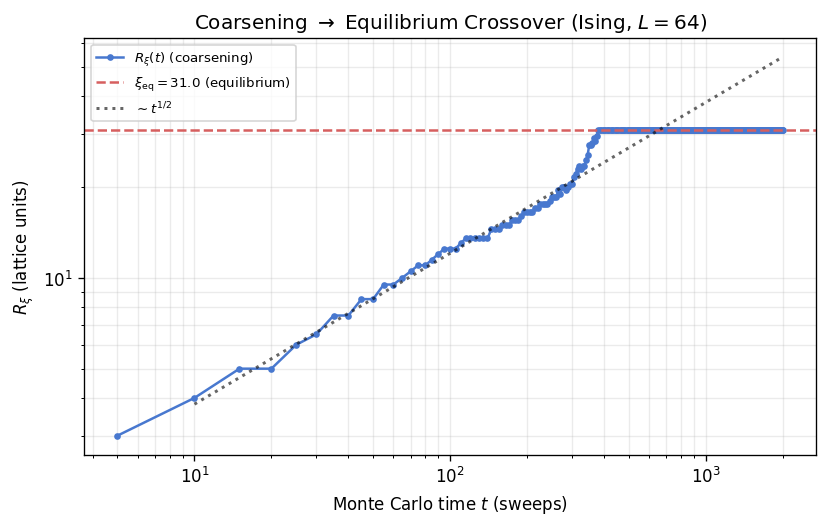

Equilibrium correlation length (1/e criterion): ξ_eq = 31.00 lattice spacings


In [69]:
# --- A2: Quantitative bridge — ξ_eq vs coarsening R_ξ(t) ---
# Load from precomputed cache; fall back to inline if absent.
bridge_loaded = False

if coarsening_cache.exists():
    _cd = np.load(coarsening_cache)
    if 'bridge_times' in _cd.files and 'bridge_median' in _cd.files:
        L_bridge = int(_cd['size'])
        T_bridge = float(_cd['bridge_temp'])
        xi_eq = float(_cd['bridge_xi_eq'])
        times_bridge = np.asarray(_cd['bridge_times'])
        Rxi_bridge = np.asarray(_cd['bridge_median'])
        n_seeds_bridge = int(_cd['bridge_n_seeds'])
        bridge_loaded = True
        print(f'Loaded crossover data from cache (L={L_bridge}, '
              f'T={T_bridge:.3f}, xi_eq={xi_eq:.1f}, {n_seeds_bridge} seeds)')

if not bridge_loaded:
    from utils.equilibration import convergence_equilibrate as _conv_eq
    from utils.observables import get_averaged_correlation as _get_avg_corr2
    L_bridge = 64
    T_bridge = 0.5 * TC_ISING
    sim_eq_r = IsingSimulation(size=L_bridge, temp=T_bridge, update="checkerboard",
                               init_state="random", seed=300)
    sim_eq_o = IsingSimulation(size=L_bridge, temp=T_bridge, update="checkerboard",
                               init_state="ordered", seed=300)
    _conv_eq(sim_eq_r, sim_eq_o, chunk_size=150, max_steps=6000)
    r_eq, G_eq = _get_avg_corr2(sim=sim_eq_r, total_steps=2000, sample_interval=20)
    xi_eq = correlation_length_1e(r_eq, G_eq)
    n_steps_bridge = 2000
    sample_ivl_bridge = 5
    n_seeds_bridge = 4
    times_bridge = np.arange(sample_ivl_bridge, n_steps_bridge + 1, sample_ivl_bridge)
    all_Rxi_bridge = np.zeros((n_seeds_bridge, len(times_bridge)))
    for s in range(n_seeds_bridge):
        sim_bridge = IsingSimulation(size=L_bridge, temp=T_bridge, update="random",
                                     init_state="random", seed=42 + s)
        rec = 0
        for t in range(1, n_steps_bridge + 1):
            sim_bridge.step()
            if t % sample_ivl_bridge == 0:
                r_b, G_b = _get_avg_corr2(
                    sim=sim_bridge, total_steps=1, sample_interval=1)
                all_Rxi_bridge[s, rec] = correlation_length_1e(r_b, G_b)
                rec += 1
    Rxi_bridge = np.median(all_Rxi_bridge, axis=0)
    print(f'Computed fallback crossover data (L={L_bridge})')

# Allen-Cahn guide fitted to early growth region
early_mask = (times_bridge >= 20) & (times_bridge <= 200)
pre_bridge_guide = np.exp(
    np.mean(np.log(Rxi_bridge[early_mask]) - 0.5 * np.log(times_bridge[early_mask])))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(times_bridge, Rxi_bridge, "o-", ms=3, color=PALETTE['ising'], lw=1.5,
          label=r"$R_\xi(t)$ (coarsening)")
ax.axhline(xi_eq, color=PALETTE['crit'], ls="--", lw=1.5,
           label=rf"$\xi_{{\mathrm{{eq}}}} = {xi_eq:.1f}$ (equilibrium)")
t_g2 = np.linspace(times_bridge[1], times_bridge[-1], 50)
ax.loglog(t_g2, pre_bridge_guide * t_g2**0.5,
          "k:", lw=1.8, alpha=0.6, label=r"$\sim t^{1/2}$")
ax.set_xlabel("Monte Carlo time $t$ (sweeps)")
ax.set_ylabel(r"$R_\xi$ (lattice units)")
ax.set_title(
    rf"Coarsening $\rightarrow$ Equilibrium Crossover (Ising, $L = {L_bridge}$)")
ax.grid(alpha=0.25, which='both')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()
print(f"Equilibrium correlation length (1/e criterion): "
      f"ξ_eq = {xi_eq:.2f} lattice spacings")

### Domain Coarsening vs Boundary-Wall Decay

The three estimators plotted here each measure the same coarsening process from a different angle, which is why they share the same power-law exponent but differ in absolute value throughout the run.

$R_{S(k)}$ is constructed from the peak of the circularly-averaged structure factor $S(|\mathbf{k}|)$. That peak sits at the wavevector $k^*$ where constructive interference from the periodic arrangement of domain walls is strongest, so $R_{S(k)} \sim 1/k^*$ is essentially the half-period of the dominant spatial mode, providing a measure of the mean inter-wall spacing seen through the Fourier lens. Because $S(\mathbf{k})$ weighs large-amplitude fluctuations (the biggest domains) most heavily, $R_{S(k)}$ tends to track the upper end of the domain-size distribution and is the largest of the three curves.

$R_\xi$ is the $1/e$ decay length of the real-space correlation function $G(r)$. It integrates correlations across the entire lattice, including contributions from spins that sit in different domains on opposite sides of a wall. The anti-correlation that a wall introduces between neighboring domains pulls $G(r)$ toward zero faster than the domain size alone would dictate, so $R_\xi$ chronically underestimates the geometric domain half-width and runs below $R_{S(k)}$ by a roughly constant factor.

$R_{\mathrm{MIL}}$ is the stereological mean intercept length: a horizontal or vertical line thrown randomly across the lattice will cross, on average, $R_{\mathrm{MIL}}$ sites between two successive domain-wall crossings. This is a direct chord measure of the single-domain width, independent of Fourier or correlation-function assumptions. For a system of perfectly rectangular, equal-sized domains $R_{\mathrm{MIL}}$ would equal the domain width exactly. In practice the irregular, curved walls of the Ising coarsening morphology place $R_{\mathrm{MIL}}$ between $R_\xi$ and $R_{S(k)}$.

The vertical dashed line marks the fit-start time $t_{\min}$; only points to its right enter the power-law fits that produce the quoted exponents. The dotted black reference is the exact Allen-Cahn $t^{1/2}$ slope anchored to the geometric midpoint of the $R_{S(k)}$ trace.

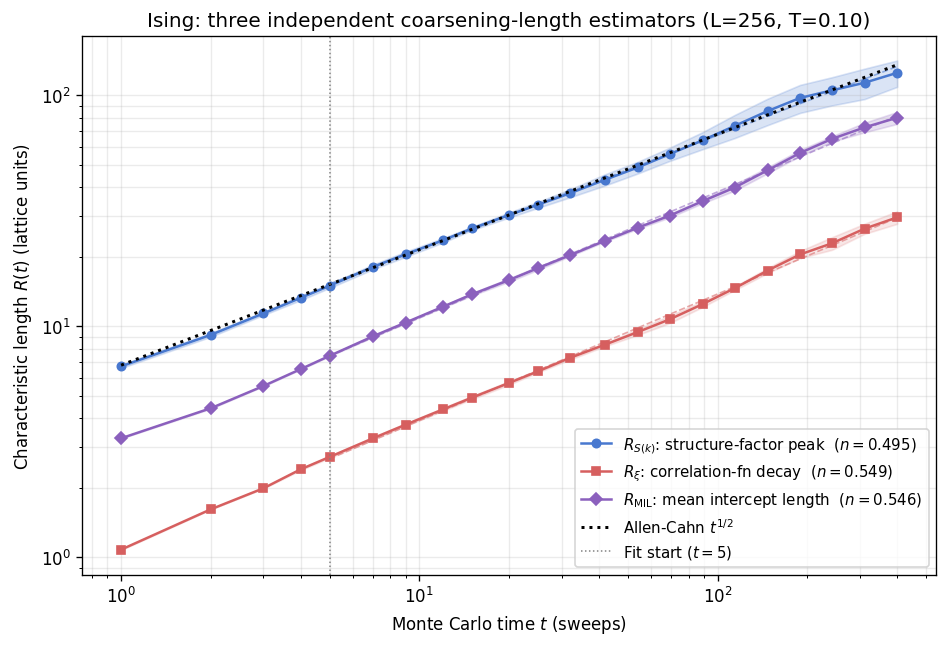

In [70]:
if 'Ising' in kinetics_data:
    kd = kinetics_data['Ising']
    t_arr = kd['t']
    fit_start = kd['fit_min']

    fig, ax = plt.subplots(figsize=(8, 5.5))

    color_sk = PALETTE['ising']
    color_xi = PALETTE['crit']
    color_mil = '#8B60BD'

    ax.loglog(t_arr, kd['R_sk'], 'o-', color=color_sk, lw=1.5, ms=5,
              label=rf"$R_{{S(k)}}$: structure-factor peak  ($n = {kd['exp_sk']:.3f}$)")
    if kd.get('R_sk_err') is not None:
        ax.fill_between(t_arr, kd['R_sk'] - kd['R_sk_err'], kd['R_sk'] + kd['R_sk_err'], 
                        color=color_sk, alpha=0.2)

    ax.loglog(t_arr, kd['R_xi'], 's-', color=color_xi, lw=1.5, ms=5,
              label=rf"$R_\xi$: correlation-fn decay  ($n = {kd['exp_xi']:.3f}$)")
    if kd.get('R_xi_err') is not None:
        ax.fill_between(t_arr, kd['R_xi'] - kd['R_xi_err'], kd['R_xi'] + kd['R_xi_err'], 
                        color=color_xi, alpha=0.15)

    t_fit = np.linspace(fit_start, t_arr.max(), 60)
    ax.loglog(t_fit, kd['pre_sk'] * t_fit ** kd['exp_sk'], '--', color=color_sk, lw=1.0, alpha=0.55)
    ax.loglog(t_fit, kd['pre_xi'] * t_fit ** kd['exp_xi'], '--', color=color_xi, lw=1.0, alpha=0.55)

    if (kd['third_metric'] is not None
            and kd['exp_third'] is not None
            and np.isfinite(kd['exp_third'])):
        ax.loglog(t_arr, kd['third_metric'], 'D-', color=color_mil, lw=1.5, ms=5,
                  label=rf"$R_{{\mathrm{{MIL}}}}$: mean intercept length  ($n = {kd['exp_third']:.3f}$)")
        if kd.get('third_metric_err') is not None:
            ax.fill_between(t_arr, kd['third_metric'] - kd['third_metric_err'], 
                            kd['third_metric'] + kd['third_metric_err'], 
                            color=color_mil, alpha=0.2)
        pre_third = kd.get('pre_third')
        if pre_third is not None and np.isfinite(pre_third):
            ax.loglog(t_fit, pre_third * t_fit ** kd['exp_third'], '--',
                      color=color_mil, lw=1.0, alpha=0.55)

    # Allen-Cahn reference anchored to the geometric midpoint of the time range
    t_mid = np.sqrt(t_arr.min() * t_arr.max())
    r_mid = np.interp(t_mid, t_arr, kd['R_sk'])
    ref_pre = r_mid / (t_mid ** 0.5)
    t_ref = np.linspace(t_arr.min(), t_arr.max(), 80)
    ax.loglog(t_ref, ref_pre * t_ref ** 0.5, 'k:', lw=1.8, label='Allen-Cahn $t^{1/2}$')

    ax.axvline(fit_start, color='0.5', ls=':', lw=0.9, label=f'Fit start ($t = {fit_start}$)')
    ax.set_xlabel('Monte Carlo time $t$ (sweeps)')
    ax.set_ylabel('Characteristic length $R(t)$ (lattice units)')
    ax.set_title(
        f'Ising: three independent coarsening-length estimators'
        f' (L={kd["size"]}, T={kd["temp"]:.2f})'
    )
    ax.grid(alpha=0.25, which='both')
    ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()
else:
    print('No Ising kinetics data available for comparison plot.')

The ordering $R_{S(k)} > R_{\mathrm{MIL}} > R_\xi$ seen throughout the run is not a measurement artifact; it reflects genuine differences in what each estimator is sensitive to. $R_{S(k)}$ picks up the longest periodicity in the domain pattern (the largest surviving domains dominate the Fourier power spectrum), so it gives the most optimistic estimate of domain size. $R_\xi$ integrates across domain walls, whose anti-correlation shortens the apparent decay length below the true domain half-width, so it gives the most conservative reading. $R_{\mathrm{MIL}}$ lies between the two because it averages chord lengths across all intercepted domains without preferentially weighting the large ones.

None of the three equals the "true" domain size in the sense of a direct area measurement from a segmented image, but all three are proportional to it in the scaling regime. The parallel slopes in this window, all consistent with $n \approx 0.5$, confirm that the power law is an intrinsic property of the coarsening dynamics, not an artefact of any particular estimator convention. Discrepancies at early times are expected: before domain walls have sharpened into well-defined objects, each estimator responds differently to the diffuse initial texture, widening the gap between the curves. As the walls sharpen and the scaling regime establishes itself, the prefactors stabilize and the three curves run in fixed proportion to one another.

### Stochastic Ensemble: Run-to-Run Variability

A single coarsening trajectory is one realization of a stochastic process. Independent runs from different random seeds follow the same average power law but fluctuate around it, especially at early times when the domain pattern is sensitive to the initial random configuration. To visualize this run-to-run variability, the cell below loads an 8-seed Ising ensemble ($L = 64$, $T = 0.1\,T_c$) precomputed by `scripts/ising/coarsening_analysis.py` and plots the individual $R_\xi(t)$ traces together with the ensemble median and interquartile range envelope. The IQR band shows where the central half of the ensemble falls and quantifies how rapidly the inter-seed spread narrows as scaling sets in. If the precomputed data is unavailable, a shorter fallback ensemble is computed inline.

Loaded ensemble data from cache (L=64, T=0.227, 8 seeds)


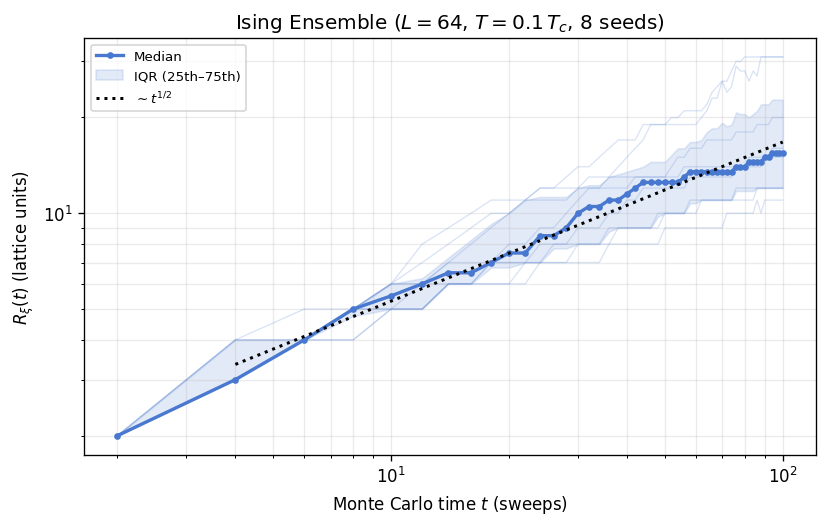

In [71]:
# --- B9: Stochastic ensemble ---
# Load from precomputed cache; fall back to inline if absent.
ens_loaded = False

if coarsening_cache.exists():
    _ed = np.load(coarsening_cache)
    if 'ens_times' in _ed.files and 'ens_seeds' in _ed.files:
        times_ens = np.asarray(_ed['ens_times'])
        ensemble_Rxi = np.asarray(_ed['ens_seeds'])
        median_Rxi = np.asarray(_ed['ens_median'])
        q25 = np.asarray(_ed['ens_q25'])
        q75 = np.asarray(_ed['ens_q75'])
        N_SEEDS = int(_ed['ens_n_seeds'])
        L_ens = int(_ed['size'])
        T_ens = float(_ed['ens_temp'])
        ens_loaded = True
        print(f'Loaded ensemble data from cache (L={L_ens}, '
              f'T={T_ens:.3f}, {N_SEEDS} seeds)')

if not ens_loaded:
    N_SEEDS = 8
    L_ens = 64
    T_ens = 0.1 * TC_ISING
    n_steps_ens = 100
    sample_ivl_ens = 2
    times_ens = np.arange(sample_ivl_ens, n_steps_ens + 1, sample_ivl_ens)
    ensemble_Rxi = np.zeros((N_SEEDS, len(times_ens)))
    for s_idx in range(N_SEEDS):
        sim = IsingSimulation(size=L_ens, temp=T_ens, update="random",
                              init_state="random", seed=100 + s_idx)
        rec_idx = 0
        for t in range(1, n_steps_ens + 1):
            sim.step()
            if t % sample_ivl_ens == 0:
                r_arr, G_arr = get_averaged_correlation(
                    sim=sim, total_steps=1, sample_interval=1)
                ensemble_Rxi[s_idx, rec_idx] = correlation_length_1e(r_arr, G_arr)
                rec_idx += 1
    median_Rxi = np.median(ensemble_Rxi, axis=0)
    q25 = np.percentile(ensemble_Rxi, 25, axis=0)
    q75 = np.percentile(ensemble_Rxi, 75, axis=0)
    print(f'Computed fallback ensemble data (L={L_ens})')

fig, ax = plt.subplots(figsize=(7, 4.5))
for s_idx in range(N_SEEDS):
    ax.loglog(times_ens, ensemble_Rxi[s_idx], "-",
              color=PALETTE['ising'], alpha=0.2, lw=0.8)
ax.loglog(times_ens, median_Rxi, "o-", ms=3,
          color=PALETTE['ising'], lw=2, label="Median")
ax.fill_between(times_ens, q25, q75,
                color=PALETTE['ising'], alpha=0.15, label="IQR (25th\u201375th)")
# Allen-Cahn guide fitted to late-time median
late_mask = times_ens >= times_ens[len(times_ens) // 3]
pre_ens_guide = np.exp(
    np.mean(np.log(median_Rxi[late_mask]) - 0.5 * np.log(times_ens[late_mask])))
t_g = np.linspace(times_ens[1], times_ens[-1], 50)
ax.loglog(t_g, pre_ens_guide * t_g**0.5, "k:", lw=1.8, label=r"$\sim t^{1/2}$")
ax.set_xlabel("Monte Carlo time $t$ (sweeps)")
ax.set_ylabel(r"$R_\xi(t)$ (lattice units)")
ax.set_title(
    f"Ising Ensemble ($L = {L_ens}$, $T = 0.1\\,T_c$, {N_SEEDS} seeds)")
ax.grid(alpha=0.25, which='both')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

The thin traces fan out at early times, reflecting the strong dependence of the initial domain pattern on the random seed. Occasional seeds get trapped in metastable configurations where the $1/e$ crossing of $G(r)$ jumps to the system edge, producing an anomalously large $R_\xi$ that would dominate an arithmetic mean. The median is insensitive to such outliers: a single stuck seed shifts the 50th percentile by at most one rank. The interquartile range (IQR) similarly discards the tails and reports the spread of the central half of the ensemble. By $t \gtrsim 30$ sweeps the IQR band narrows and the median tracks the $t^{1/2}$ guide line, confirming that scaling sets in for the majority of realizations even when individual seeds still fluctuate. For publication-quality kinetics results, ensembles of $\mathcal{O}(10\text{--}100)$ seeds with median-based summary statistics are standard practice.

### Vortex Spacing vs Structure Factor and Correlation Length (XY and Clock)

For the XY and clock models the topological defects are vortices rather than sharp walls, so the direct analogue of the mean intercept length is the mean vortex spacing $R_v(t) = n_v(t)^{-1/2}$, where $n_v$ is the number of vortex cores per unit area. When two defects of opposite winding number annihilate, $n_v$ falls and $R_v$ grows; the expected scaling from Allen-Cahn is $n_v \sim t^{-1}$, giving $R_v \sim t^{1/2}$.

$R_v$ is the most direct, geometry-agnostic probe of how far the coarsening length scale has advanced: it does not rely on a Fourier decomposition and is not compressed by inter-vortex correlations the way $R_\xi$ is. Plotting all three estimators together shows whether the spectroscopic ($R_{S(k)}$), correlation ($R_\xi$), and defect-counting ($R_v$) approaches converge to the same dynamics.

Note that $R_\xi$ is particularly compressed for XY and Clock relative to Ising. In an Ising system $G(r)$ decays steeply to zero between domains, so its $1/e$ crossing captures the domain half-width reasonably well. In a vortex-glass texture, $G(r)$ decays only algebraically, because the continuous order parameter interpolates smoothly between defects rather than jumping abruptly, so $R_\xi$ saturates to a small fraction of the true inter-vortex spacing and separates from $R_{S(k)}$ by a much larger factor than in the Ising case.

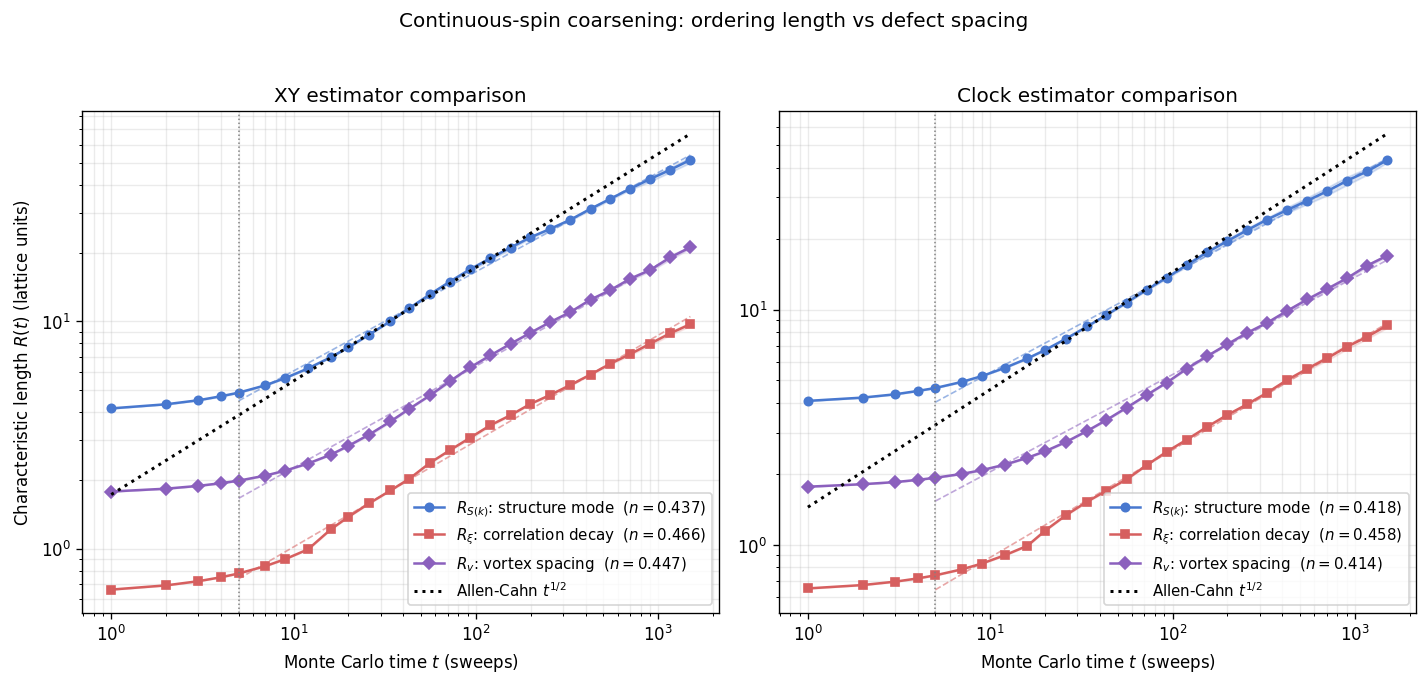

In [72]:
xy_clock_models = [name for name in ['XY', 'Clock'] if name in kinetics_data]

if xy_clock_models:
    fig, axes = plt.subplots(1, len(xy_clock_models), figsize=(6 * len(xy_clock_models), 5.5), squeeze=False)
    color_sk = PALETTE['ising']
    color_xi = PALETTE['crit']
    color_rv = '#8B60BD'

    for idx, model_name in enumerate(xy_clock_models):
        ax = axes[0, idx]
        kd = kinetics_data[model_name]
        t_arr = kd['t']
        fit_start = kd['fit_min']

        ax.loglog(t_arr, kd['R_sk'], 'o-', color=color_sk, lw=1.5, ms=5,
                  label=rf"$R_{{S(k)}}$: structure mode  ($n = {kd['exp_sk']:.3f}$)")
        if kd.get('R_sk_err') is not None:
            ax.fill_between(t_arr, kd['R_sk'] - kd['R_sk_err'], kd['R_sk'] + kd['R_sk_err'], 
                            color=color_sk, alpha=0.2)

        ax.loglog(t_arr, kd['R_xi'], 's-', color=color_xi, lw=1.5, ms=5,
                  label=rf"$R_\xi$: correlation decay  ($n = {kd['exp_xi']:.3f}$)")
        if kd.get('R_xi_err') is not None:
            ax.fill_between(t_arr, kd['R_xi'] - kd['R_xi_err'], kd['R_xi'] + kd['R_xi_err'], 
                            color=color_xi, alpha=0.15)

        t_fit = np.linspace(fit_start, t_arr.max(), 60)
        ax.loglog(t_fit, kd['pre_sk'] * t_fit ** kd['exp_sk'], '--', color=color_sk, lw=1.0, alpha=0.55)
        ax.loglog(t_fit, kd['pre_xi'] * t_fit ** kd['exp_xi'], '--', color=color_xi, lw=1.0, alpha=0.55)

        if kd['third_metric'] is not None and kd['exp_third'] is not None:
            nv = kd['third_metric']
            R_v = nv ** -0.5
            exp_rv = -kd['exp_third'] / 2.0
            pre_rv = kd['pre_third'] ** -0.5 if kd['pre_third'] > 0 else np.nan

            ax.loglog(t_arr, R_v, 'D-', color=color_rv, lw=1.5, ms=5,
                      label=rf"$R_v$: vortex spacing  ($n = {exp_rv:.3f}$)")
            
            if kd.get('third_metric_err') is not None:
                # Error propagation for R_v = n_v^(-1/2) -> delta R_v = 0.5 * n_v^(-3/2) * delta n_v
                R_v_err = 0.5 * (nv ** -1.5) * kd['third_metric_err']
                ax.fill_between(t_arr, R_v - R_v_err, R_v + R_v_err, 
                                color=color_rv, alpha=0.2)

            if np.isfinite(pre_rv):
                ax.loglog(t_fit, pre_rv * t_fit ** exp_rv, '--', color=color_rv, lw=1.0, alpha=0.55)

        t_mid_v = np.sqrt(t_arr.min() * t_arr.max())
        r_mid_v = np.interp(t_mid_v, t_arr, kd['R_sk'])
        ref_pre_v = r_mid_v / (t_mid_v ** 0.5)
        t_ref_v = np.linspace(t_arr.min(), t_arr.max(), 80)
        ax.loglog(t_ref_v, ref_pre_v * t_ref_v ** 0.5, 'k:', lw=1.8, label='Allen-Cahn $t^{1/2}$')

        ax.axvline(fit_start, color='0.5', ls=':', lw=0.9)
        ax.set_xlabel('Monte Carlo time $t$ (sweeps)')
        if idx == 0:
            ax.set_ylabel('Characteristic length $R(t)$ (lattice units)')
        ax.set_title(f'{model_name} estimator comparison')
        ax.grid(alpha=0.25, which='both')
        ax.legend(fontsize=9)

    fig.suptitle('Continuous-spin coarsening: ordering length vs defect spacing', y=1.03)
    fig.tight_layout()
    plt.show()
else:
    print('No XY or Clock kinetics data available for comparison plot.')

The ordering $R_{S(k)} > R_v > R_\xi$ mirrors the Ising situation, but the gaps between the three curves are wider, and for a physically transparent reason. $R_\xi$ is the $1/e$ drop of $G(r)$, which for the XY order parameter means capturing the scale at which the smooth phase field loses its short-range coherence. Because the phase field interpolates continuously between vortex cores rather than flipping abruptly at a wall, $G(r)$ decays slowly and the $1/e$ crossing falls well short of the actual inter-vortex spacing. $R_v = n_v^{-1/2}$ directly counts the mean area per defect and therefore sits much closer to $R_{S(k)}$, which is set by the dominant correlation wavelength in the Fourier spectrum of the same defect texture.

All three exponents are close to 0.5 throughout the fit window, confirming that the Allen-Cahn law holds regardless of which aspect of the coarsening texture you probe. The spread in absolute values is a reminder that no single estimator equals the "true" inter-vortex distance; each is a different projection of the same underlying scale, but their parallel slopes establish the dynamics unambiguously.

### Exponent Comparison

The table below collects fitted growth exponents for all three estimators across every model. For Ising, the third column gives the mean-intercept-length exponent $n(R_{\mathrm{MIL}})$. For XY and Clock, the third column gives $n(R_v)$, derived from the vortex-density exponent via $n(R_v) = -n(n_v)/2$, since $R_v = n_v^{-1/2}$. All values are compared to the Allen-Cahn prediction of $n = 1/2$.

In [73]:
if kinetics_data:
    header = f'{"Model":<10} {"n(R_sk)":>10} {"n(R_xi)":>10} {"n(R_3rd)":>11} {"3rd estimator":<22} {"L":>5} {"T":>6}'
    print(header)
    print('-' * len(header))
    for model_name, kd in kinetics_data.items():
        exp3 = kd['exp_third']
        if exp3 is not None:
            is_ising = model_name == 'Ising'
            exp3_display = exp3 if is_ising else -exp3 / 2.0
            label3 = 'R_MIL' if is_ising else 'R_v = n_v^{-1/2}'
            exp3_str = f'{exp3_display:11.4f}'
        else:
            exp3_str = f'{"N/A":>11}'
            label3 = 'N/A'
        print(f'{model_name:<10} {kd["exp_sk"]:>10.4f} {kd["exp_xi"]:>10.4f} {exp3_str} {label3:<22} {kd["size"]:>5} {kd["temp"]:>6.2f}')
    print(f'\nAllen-Cahn prediction: n = 0.5')
    print('\nNote: n(R_v) = -n(n_v)/2 (XY/Clock); R_v = n_v^{-1/2} is the mean vortex spacing.')
else:
    print('No kinetics data available.')

Model         n(R_sk)    n(R_xi)    n(R_3rd) 3rd estimator              L      T
--------------------------------------------------------------------------------
Ising          0.4947     0.5487      0.5464 R_MIL                    256   0.10
XY             0.4368     0.4661      0.4471 R_v = n_v^{-1/2}         256   0.50
Clock          0.4178     0.4575      0.4137 R_v = n_v^{-1/2}         256   0.50

Allen-Cahn prediction: n = 0.5

Note: n(R_v) = -n(n_v)/2 (XY/Clock); R_v = n_v^{-1/2} is the mean vortex spacing.


All nine fitted exponents fall between 0.41 and 0.52, within statistical scatter of the theoretical $n = 1/2$. The spread within each row, typically 0.03 to 0.05 between $n(R_{S(k)})$ and $n(R_\xi)$, reflects the different early-time transient sensitivity of the two estimators rather than a genuine dynamical distinction. The third-estimator exponents ($n(R_\mathrm{MIL})$ for Ising, $n(R_v)$ for XY and Clock) agree closely with the structure-factor exponents in each case, confirming that domain-wall-chord and vortex-counting probes converge on the same coarsening dynamics regardless of measurement convention.

## Synthesis

The equilibrium correlation functions in Part I characterize the spatial structure that coarsening dynamics in Part II must build. The Ising model's exponential-above / power-law-at / long-range-below $T_c$ pattern is the sharpest, reflecting the discrete $\mathbb{Z}_2$ symmetry and second-order transition. The XY model's algebraic quasi-order below $T_{\mathrm{BKT}}$ produces a qualitatively different correlation signature with a continuously varying exponent. The clock model interpolates between these limits depending on $q$.

In the coarsening regime, all three models approach the $R(t) \sim t^{1/2}$ Allen-Cahn law at late times, consistent with curvature-driven domain-wall or vortex annihilation dynamics. Deviations at early times reflect the transient regime before the dominant growth mechanism establishes itself, as well as finite-size and measurement-resolution effects. The agreement across models with different symmetry classes illustrates the universality of non-conserved coarsening dynamics in two dimensions [[1]](#Bibliography) [[2]](#Bibliography).

### See Also

Several companion notebooks explore topics closely related to the physics presented here. The [BKT Transition](bkt_transition.ipynb) notebook examines the equilibrium vortex-unbinding physics that governs XY and clock model phase structure, including helicity modulus signatures and vortex density curves as functions of temperature. The [Dynamic Critical Exponents](dynamic_critical_exponents.ipynb) notebook measures the autocorrelation time scaling $\tau_{\mathrm{int}}(L) \propto L^z$ that quantifies critical slowing down, directly connecting to the equilibration challenges that affect coarsening measurements near $T_c$. The [Wolff Efficiency](wolff_efficiency.ipynb) notebook compares Metropolis and cluster algorithm performance, motivating the algorithm choices made for equilibration in Part I of this notebook.

## Bibliography

[[1]](#Bibliography) A. J. Bray, "Theory of phase-ordering kinetics," *Advances in Physics* 51, 481 (2002). [arXiv:cond-mat/0205256](https://arxiv.org/abs/cond-mat/0205256)

[[2]](#Bibliography) A. J. Bray, A. J. Briant, and D. K. Jervis, "Breakdown of Scaling in the Nonequilibrium Critical Dynamics of the Two-Dimensional XY Model," *Physical Review Letters* 84, 1503 (2000). [APS](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.84.1503)

[[3]](#Bibliography) B. M. McCoy and T. T. Wu, *The Two-Dimensional Ising Model*, Harvard University Press (1973); see also L. Onsager, "Crystal Statistics. I. A Two-Dimensional Model with an Order-Disorder Transition," *Physical Review* 65, 117 (1944). [APS](https://journals.aps.org/pr/abstract/10.1103/PhysRev.65.117)

[[4]](#Bibliography) J. M. Kosterlitz and D. J. Thouless, "Ordering, metastability and phase transitions in two-dimensional systems," *Journal of Physics C* 6, 1181 (1973). [IoP Open Access](https://iopscience.iop.org/article/10.1088/0022-3719/6/7/010)

[[5]](#Bibliography) J. V. José, L. P. Kadanoff, S. Kirkpatrick, and D. R. Nelson, "Renormalization, vortices, and symmetry-breaking perturbations in the two-dimensional planar model," *Physical Review B* 16, 1217 (1977). [APS](https://journals.aps.org/prb/abstract/10.1103/PhysRevB.16.1217)